In [3]:
import pandas as pd

df = pd.read_csv('final_data_cleaned.csv')

# Y
df['Dispute_Rate'] = df['consumer_disputed?']

# X1: Institution Type (Specialist)
df['Is_Specialist'] = (df['institution_type'] == 'Specialist').astype(int)

# X2: Enforcement
df['Has_Enforcement'] = df['enforcement_action']

# X3: Assets
df['Assets_Billions'] = df['sl_assets_billions']

# X4: Issue (Two Main Issues)
df['Issue_Servicing'] = (df['issue'] == "Dealing with my lender or servicer").astype(int)
df['Issue_Cant_Repay'] = (df['issue'] == "Can't repay my loan").astype(int)

# X5: Submission Channel (Mainly Web and Referral)
df['Channel_Web'] = (df['submission_group'] == 'Web').astype(int)
df['Channel_Referral'] = (df['submission_group'] == 'Referral').astype(int)

# --- Generate Summary Statistics Table ---
summary_vars = [
    'Dispute_Rate',      # Outcome
    'Is_Specialist',     # Firm X
    'Has_Enforcement',   # Firm X
    'Assets_Billions',   # Firm X
    'Issue_Servicing',   # Complaint X
    'Issue_Cant_Repay',  # Complaint X
    'Channel_Web',       # Complaint X
    'Channel_Referral'   # Complaint X
]

summary_table = df[summary_vars].describe().T[['count', 'mean', 'std', 'min', 'max']]

print("=== Table 1: Summary Statistics ===")
try:
    from IPython.display import display
    display(summary_table)
except:
    print(summary_table)

=== Table 1: Summary Statistics ===


,count,mean,std,min,max
Dispute_Rate,13015.0,0.195620,0.396693,0.0,1.0
Is_Specialist,13015.0,0.756051,0.429479,0.0,1.0
Has_Enforcement,13015.0,0.615982,0.486381,0.0,1.0
Assets_Billions,13015.0,83.436857,58.461625,0.5,134.0
Issue_Servicing,13015.0,0.617134,0.486105,0.0,1.0
Issue_Cant_Repay,13015.0,0.354668,0.478431,0.0,1.0
Channel_Web,13015.0,0.869228,0.337164,0.0,1.0
Channel_Referral,13015.0,0.066308,0.248829,0.0,1.0


In [ ]:
df = pd.read_csv('final_data_cleaned.csv')
df['sub_issue'].value_counts()

sub_issue
Repaying your loan                         3426
Trouble with how payments are handled      1635
Problems when you are unable to pay        1447
Can't decrease my monthly payments         1338
Can't get flexible payment options         1265
Received bad information about my loan      821
Having problems with customer service       751
Can't temporarily postpone payments         566
Don't agree with fees charged               542
Keep getting calls about my loan            491
Need information about my balance/terms     366
Getting a loan                              181
Can't qualify for a loan                    110
Qualify for a better loan than offered       76
Name: count, dtype: int64

In [4]:
df['issue_group'] = df['sub_issue'].replace({
    'Repaying your loan': 'Repayment difficulty',
    'Problems when you are unable to pay': 'Repayment difficulty',
    "Can't decrease my monthly payments": 'Repayment difficulty',
    "Can't get flexible payment options": 'Repayment difficulty',
    "Can't temporarily postpone payments": 'Repayment difficulty',

    'Trouble with how payments are handled': 'Payment processing',
    "Don't agree with fees charged": 'Payment processing',

    'Received bad information about my loan': 'Servicing problems',
    'Having problems with customer service': 'Servicing problems',
    'Need information about my balance/terms': 'Servicing problems',

    'Getting a loan': 'Loan access',
    "Can't qualify for a loan": 'Loan access',
    'Qualify for a better loan than offered': 'Loan access'
})

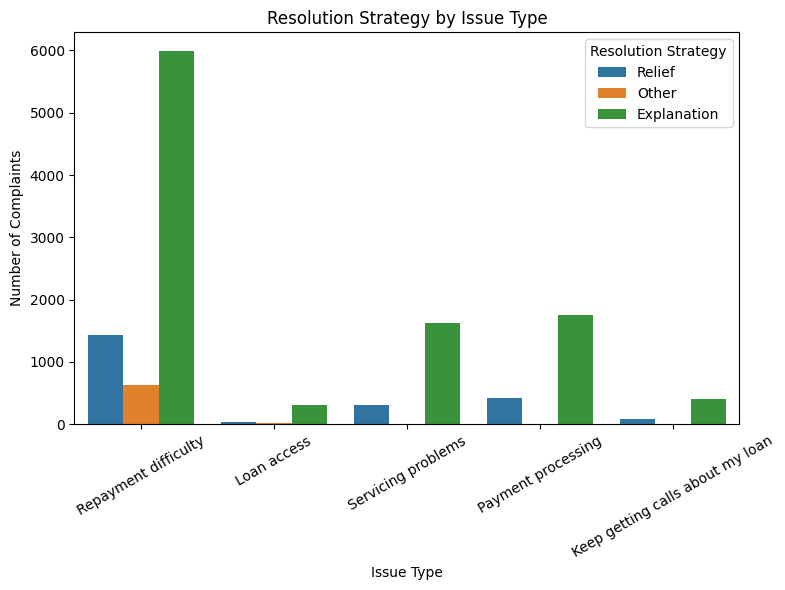

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))

sns.countplot(
    data=df,
    x="issue_group",
    hue="company_response_to_consumer"
)

plt.title("Resolution Strategy by Issue Type")
plt.xlabel("Issue Type")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=30)

plt.legend(title="Resolution Strategy")
plt.tight_layout()
plt.show()

In [6]:
strategy_share = (
    df.groupby(['issue_group','company_response_to_consumer'], as_index=False)
    .size()
)

strategy_share['share'] = (
    strategy_share.groupby('issue_group')['size']
    .transform(lambda x: x/x.sum())
)

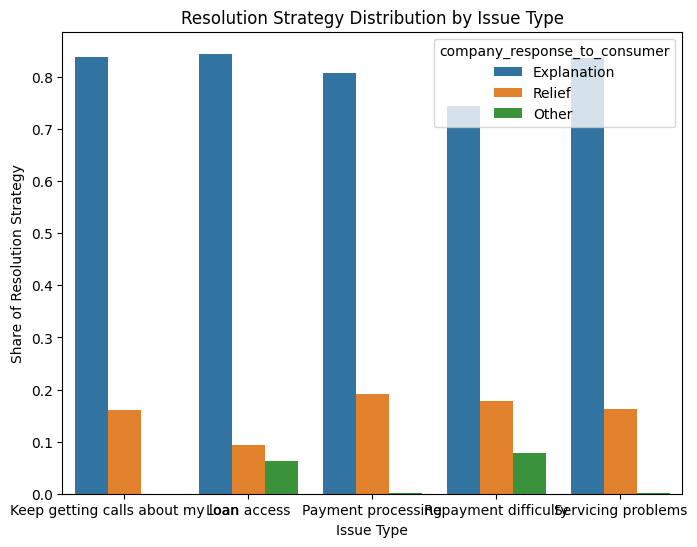

In [ ]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=strategy_share,
    x='issue_group',
    y='share',
    hue='company_response_to_consumer'
)

plt.title("Resolution Strategy Distribution by Issue Type")
plt.xlabel("Issue Type")
plt.ylabel("Share of Resolution Strategy")

plt.show()

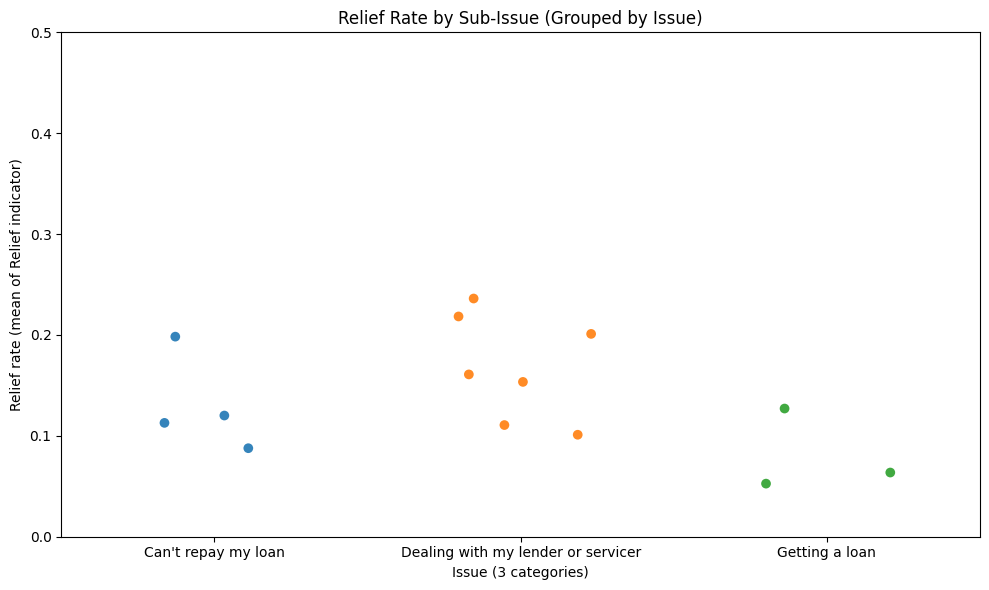

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 读数据（如果你已经读过 df，就跳过这行）
df = pd.read_csv("final_data_cleaned.csv")

# 1) 定义 relief indicator：公司回应是 Relief 就记为1，否则0
df["is_relief"] = (df["company_response_to_consumer"] == "Relief").astype(int)

# 2) 计算每个 (issue, sub_issue) 的 relief rate
sub_relief = (
    df.groupby(["issue", "sub_issue"], as_index=False)["is_relief"]
      .mean()
      .rename(columns={"is_relief": "relief_rate"})
)

# （可选）按每个 issue 内 relief_rate 排序，让点更好看
sub_relief = sub_relief.sort_values(["issue", "relief_rate"])

# 3) 画图：每个 sub_issue 一个点，x=issue 三大块，y=relief_rate，颜色也按 issue
plt.figure(figsize=(10, 6))
ax = sns.stripplot(
    data=sub_relief,
    x="issue",
    y="relief_rate",
    hue="issue",        # 三种颜色区分三大 issue
    jitter=0.25,        # 让点左右抖动，避免重叠
    dodge=False,        # 不需要把 hue 再分开（因为 hue 就是 x）
    size=7,
    alpha=0.9
)

ax.set_title("Relief Rate by Sub-Issue (Grouped by Issue)")
ax.set_xlabel("Issue (3 categories)")
ax.set_ylabel("Relief rate (mean of Relief indicator)")
ax.set_ylim(0, 0.5)

# 因为 hue 和 x 一样，图例会有点重复，保留即可；或你也可以关掉：
# ax.legend_.remove()

plt.tight_layout()
plt.show()

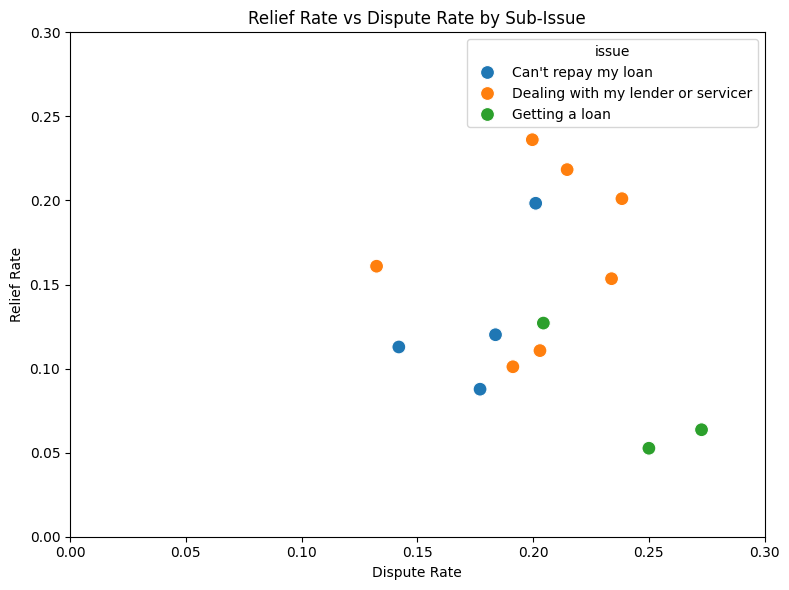

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 如果已经读过数据可以跳过
df = pd.read_csv("final_data_cleaned.csv")

# relief indicator
df["is_relief"] = (df["company_response_to_consumer"] == "Relief").astype(int)

# dispute indicator
df["is_dispute"] = (df["consumer_disputed?"] == 1).astype(int)

# 计算每个 sub_issue 的 relief rate 和 dispute rate
sub_stats = (
    df.groupby(["issue","sub_issue"], as_index=False)
    .agg(
        relief_rate=("is_relief","mean"),
        dispute_rate=("is_dispute","mean")
    )
)

# 画 scatter
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=sub_stats,
    x="dispute_rate",
    y="relief_rate",
    hue="issue",
    s=100
)

plt.xlabel("Dispute Rate")
plt.ylabel("Relief Rate")
plt.title("Relief Rate vs Dispute Rate by Sub-Issue")
plt.xlim(0,0.3)
plt.ylim(0,0.3)

plt.tight_layout()
plt.show()

In [8]:
sns.boxplot(
    data=sub_stats,
    x="issue",
    y="relief_rate"
)

NameError: name 'sub_stats' is not defined

<Axes: xlabel='issue', ylabel='dispute_rate'>

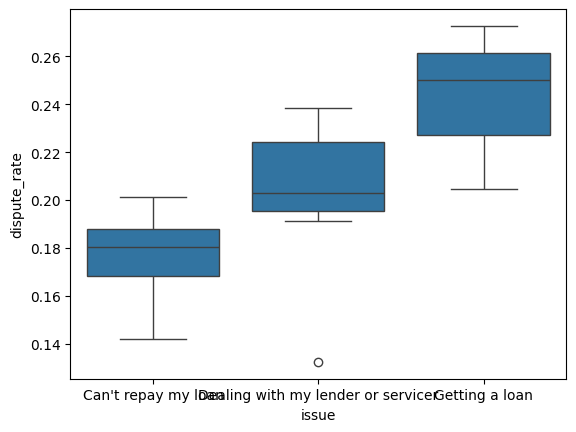

In [ ]:
sns.boxplot(
    data=sub_stats,
    x="issue",
    y="dispute_rate"
)

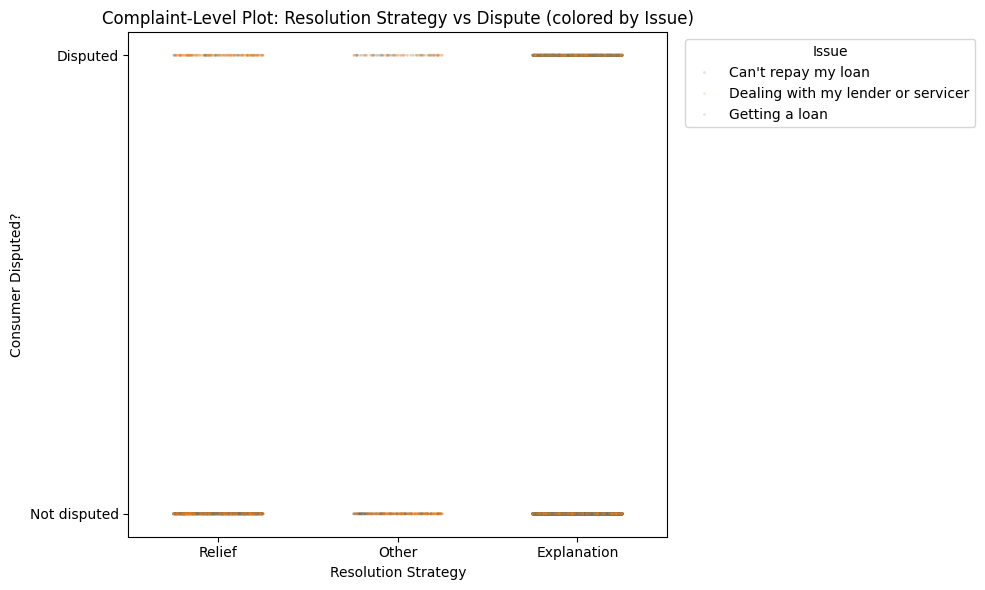

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("final_data_cleaned.csv")

# （可选）把 response 也清理一下
df["response_clean"] = (
    df["company_response_to_consumer"]
      .astype(str).str.strip()
)

plt.figure(figsize=(10, 6))

sns.stripplot(
    data=df,
    x="response_clean",        # 3类：Explanation / Other / Relief
    y="consumer_disputed?",           # 0/1 两类
    hue="issue",               # 3种颜色：issue
    jitter=0.25,               # 让点左右抖动
    dodge=False,
    alpha=0.18,                # 透明度！不然会糊成一坨
    size=2,                    # 点小一点
)

plt.yticks([0, 1], ["Not disputed", "Disputed"])
plt.xlabel("Resolution Strategy")
plt.ylabel("Consumer Disputed?")
plt.title("Complaint-Level Plot: Resolution Strategy vs Dispute (colored by Issue)")
plt.legend(title="Issue", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

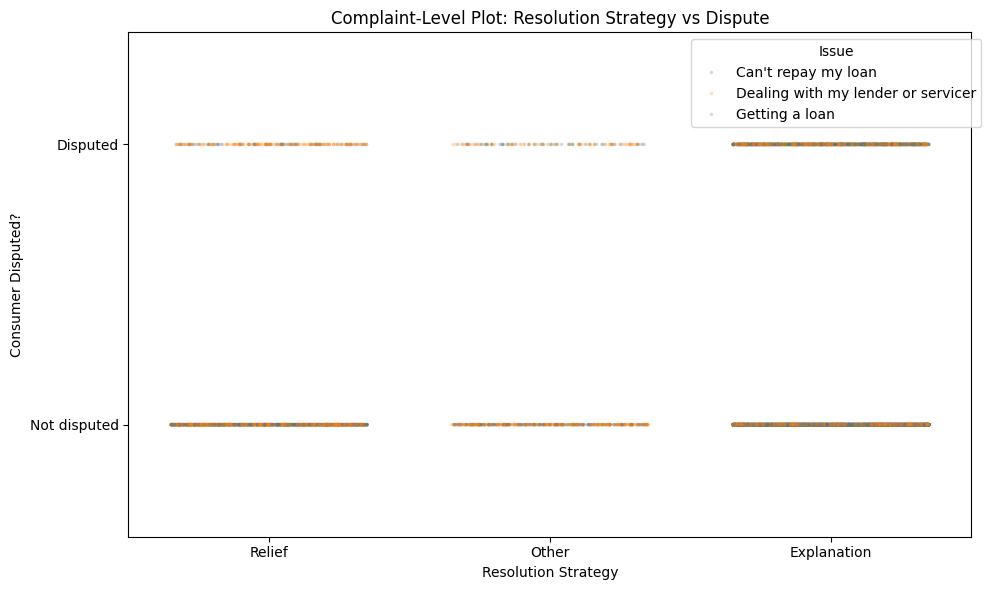

In [10]:
plt.figure(figsize=(10,6))

sns.stripplot(
    data=df,
    x="response_clean",
    y="consumer_disputed?",
    hue="issue",
    jitter=0.35,        # x方向散开
    alpha=0.25,
    size=2.5
)

# 手动让y轴有一点上下空间
plt.ylim(-0.4,1.4)

plt.yticks([0,1],["Not disputed","Disputed"])
plt.xlabel("Resolution Strategy")
plt.ylabel("Consumer Disputed?")
plt.title("Complaint-Level Plot: Resolution Strategy vs Dispute")

plt.legend(title="Issue", bbox_to_anchor=(1.02,1))
plt.tight_layout()
plt.show()

<Axes: xlabel='response_clean', ylabel='consumer_disputed?'>

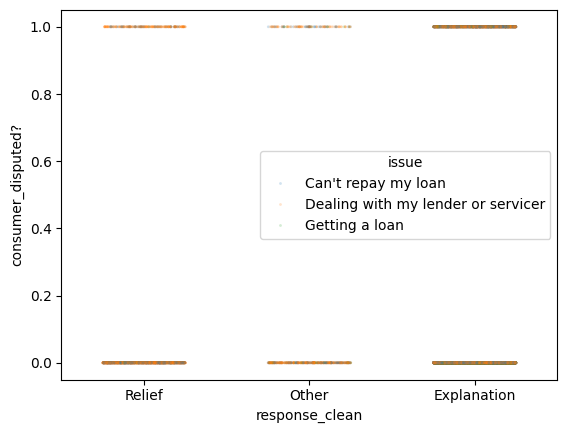

In [11]:
sns.stripplot(
    data=df,
    x="response_clean",
    y="consumer_disputed?",
    hue="issue",
    jitter=0.25,
    alpha=0.2,
    size=2
)

In [13]:
import numpy as np

df["dispute_jitter"] = df["consumer_disputed?"] + np.random.uniform(-0.1, 0.1, size=len(df))

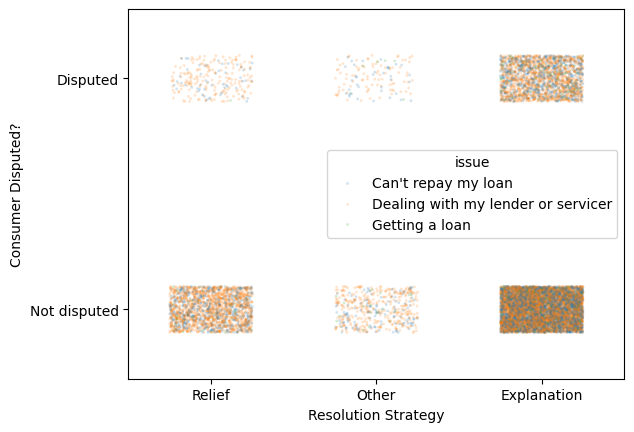

In [14]:
sns.stripplot(
    data=df,
    x="response_clean",
    y="dispute_jitter",
    hue="issue",
    jitter=0.25,
    alpha=0.2,
    size=2
)

plt.yticks([0, 1], ["Not disputed", "Disputed"])
plt.ylim(-0.3, 1.3)
plt.xlabel("Resolution Strategy")
plt.ylabel("Consumer Disputed?")
plt.show()

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 每条 complaint 的 dispute_bin（如果你已经有就跳过）
df["dispute_bin"] = (
    df["consumer_disputed?"]
      .astype(str).str.strip().str.lower()
      .isin(["yes", "1", "true"])
      .astype(int)
)

# y 轴抖动，让 0/1 上下散开
rng = np.random.default_rng(42)
df["dispute_jitter"] = df["dispute_bin"] + rng.uniform(-0.12, 0.12, size=len(df))

# 每个 strategy 取最小组的数量（也可以自己设 n_per，比如 800）
counts = df["response_clean"].value_counts()
n_per = counts.min()   # 三类中最小的那个数量
# n_per = 800          # 或者你手动指定

df_bal = (
    df.groupby("response_clean", group_keys=False)
      .apply(lambda x: x.sample(n=n_per, random_state=42))
)

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df_bal,
    x="response_clean",
    y="dispute_jitter",
    hue="issue",
    s=8,
    alpha=0.25
)
plt.yticks([0,1], ["Not disputed", "Disputed"])
plt.ylim(-0.35, 1.35)
plt.xlabel("Resolution Strategy (balanced sample)")
plt.ylabel("Consumer Disputed?")
plt.title(f"Balanced by Strategy (n={n_per} per strategy)")
plt.legend(title="Issue", bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.show()

ValueError: Could not interpret value `response_clean` for `x`. An entry with this name does not appear in `data`.

<Figure size 1000x600 with 0 Axes>

In [16]:
df.columns

Index(['date_received', 'product', 'issue', 'sub_issue',
       'consumer_complaint_narrative', 'company_public_response', 'company',
       'state', 'zipcode', 'tags', 'consumer_consent_provided',
       'submitted_via', 'date_sent_to_company', 'company_response_to_consumer',
       'timely_response', 'consumer_disputed?', 'complaint_id',
       'institution_type', 'enforcement_action', 'sl_assets_billions',
       'submission_group', 'complaint_year', 'response_clean',
       'dispute_jitter', 'dispute_bin'],
      dtype='str')

In [17]:
n_per = df["response_clean"].value_counts().min()

df_bal = (
    df.groupby("response_clean", group_keys=False)
      .apply(lambda x: x.sample(n=n_per, random_state=42))
)

In [18]:
sns.scatterplot(
    data=df_bal,
    x="response_clean",
    y="dispute_jitter",
    hue="issue",
    s=8,
    alpha=0.25
)

ValueError: Could not interpret value `response_clean` for `x`. An entry with this name does not appear in `data`.

In [19]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1) 保险起见：确认 df 里确实有这列
assert "response_clean" in df.columns, "df 里没有 response_clean（但你刚刚贴的 columns 显示有）"

# 2) 平衡抽样：每个 strategy 抽同样数量
n_per = df["response_clean"].value_counts().min()

df_bal = (
    df.groupby("response_clean", group_keys=False)
      .apply(lambda x: x.sample(n=n_per, random_state=42))
      .reset_index(drop=True)
)

# 3) 再次确认 df_bal 没丢列（关键）
assert "response_clean" in df_bal.columns, "df_bal 里没有 response_clean（说明你前面某步把列筛掉/覆盖了）"

# 4) 画图（你已经有 dispute_jitter 了就直接用；没有的话我这里顺便补上）
if "dispute_jitter" not in df_bal.columns:
    if "dispute_bin" not in df_bal.columns:
        df_bal["dispute_bin"] = (
            df_bal["consumer_disputed?"].astype(str).str.strip().str.lower().eq("yes").astype(int)
        )
    rng = np.random.default_rng(42)
    df_bal["dispute_jitter"] = df_bal["dispute_bin"] + rng.uniform(-0.12, 0.12, size=len(df_bal))

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df_bal,
    x="response_clean",
    y="dispute_jitter",
    hue="issue",
    s=10,
    alpha=0.25
)
plt.yticks([0,1], ["Not disputed", "Disputed"])
plt.ylim(-0.35, 1.35)
plt.xlabel("Resolution Strategy (balanced sample)")
plt.ylabel("Consumer Disputed?")
plt.title(f"Balanced Sample: n={n_per} per strategy")
plt.legend(title="Issue", bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.show()

AssertionError: df_bal 里没有 response_clean（说明你前面某步把列筛掉/覆盖了）

In [20]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 0) 确保 response_clean 存在
print("has response_clean in df?", "response_clean" in df.columns)

# 1) 取每个 strategy 的最小样本量
n_per = df["response_clean"].value_counts().min()
print("n_per =", n_per)

# 2) 用 groupby().sample() 平衡抽样（不会丢列）
df_bal = (
    df.groupby("response_clean", group_keys=False)
      .sample(n=n_per, random_state=42)
      .reset_index(drop=True)
)

print("has response_clean in df_bal?", "response_clean" in df_bal.columns)
print(df_bal.columns)

has response_clean in df? True
n_per = 652
has response_clean in df_bal? True
Index(['date_received', 'product', 'issue', 'sub_issue',
       'consumer_complaint_narrative', 'company_public_response', 'company',
       'state', 'zipcode', 'tags', 'consumer_consent_provided',
       'submitted_via', 'date_sent_to_company', 'company_response_to_consumer',
       'timely_response', 'consumer_disputed?', 'complaint_id',
       'institution_type', 'enforcement_action', 'sl_assets_billions',
       'submission_group', 'complaint_year', 'response_clean',
       'dispute_jitter', 'dispute_bin'],
      dtype='str')


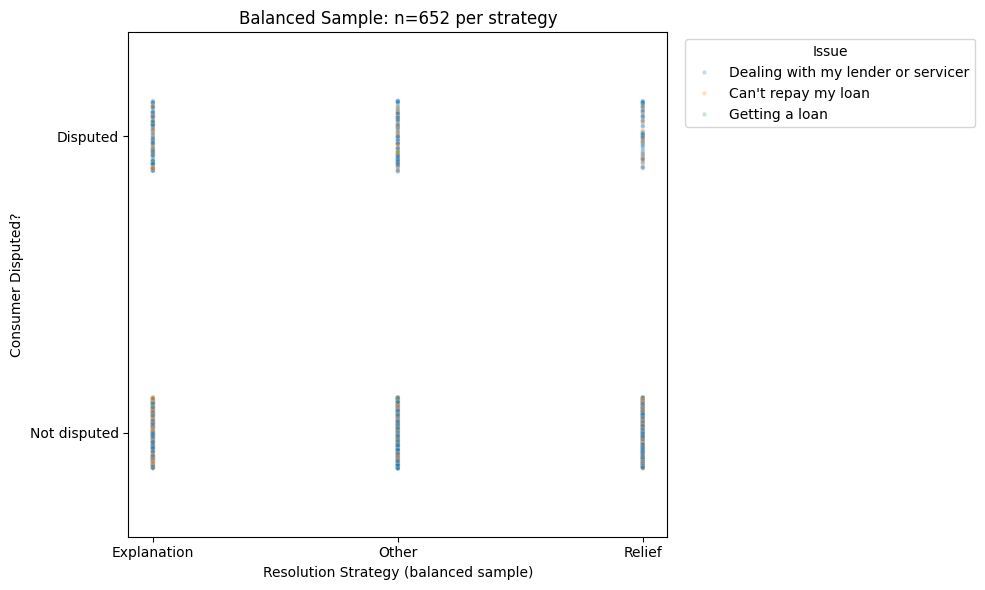

In [21]:
rng = np.random.default_rng(42)
df_bal["dispute_jitter"] = df_bal["dispute_bin"] + rng.uniform(-0.12, 0.12, size=len(df_bal))

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df_bal,
    x="response_clean",
    y="dispute_jitter",
    hue="issue",
    s=10,
    alpha=0.25
)

plt.yticks([0,1], ["Not disputed", "Disputed"])
plt.ylim(-0.35, 1.35)
plt.xlabel("Resolution Strategy (balanced sample)")
plt.ylabel("Consumer Disputed?")
plt.title(f"Balanced Sample: n={n_per} per strategy")
plt.legend(title="Issue", bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.show()

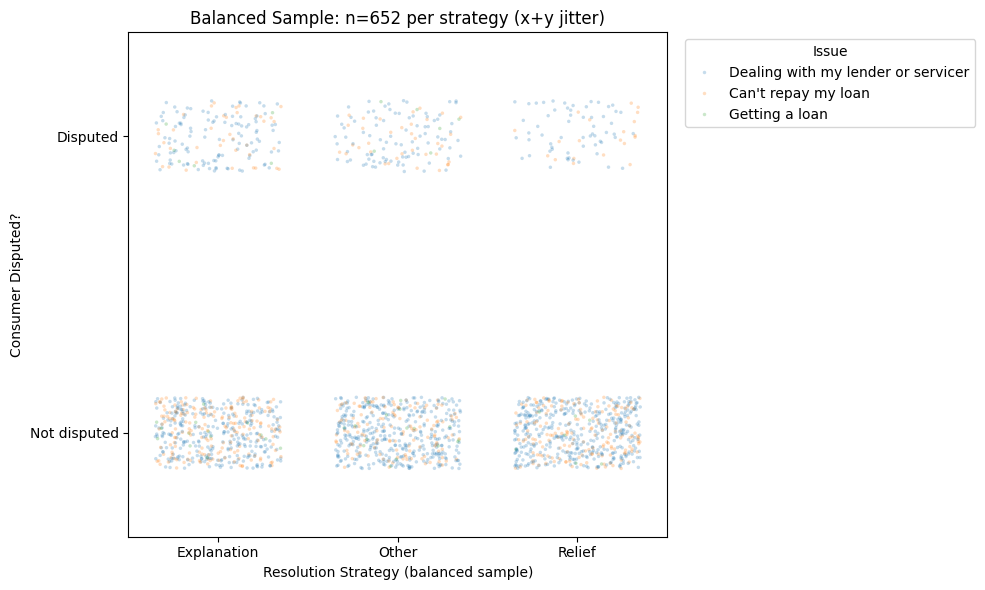

In [22]:
plt.figure(figsize=(10,6))
sns.stripplot(
    data=df_bal,
    x="response_clean",
    y="dispute_jitter",   # 你已经做了上下抖动
    hue="issue",
    jitter=0.35,          # 这就是左右抖动
    dodge=False,
    alpha=0.25,
    size=2.5
)

plt.yticks([0,1], ["Not disputed", "Disputed"])
plt.ylim(-0.35, 1.35)
plt.xlabel("Resolution Strategy (balanced sample)")
plt.ylabel("Consumer Disputed?")
plt.title(f"Balanced Sample: n={n_per} per strategy (x+y jitter)")
plt.legend(title="Issue", bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.show()